<a href="https://colab.research.google.com/github/aqilfiras/California-Housing-Prices-Prediction/blob/main/house_pricing_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('data/california_housing_train.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


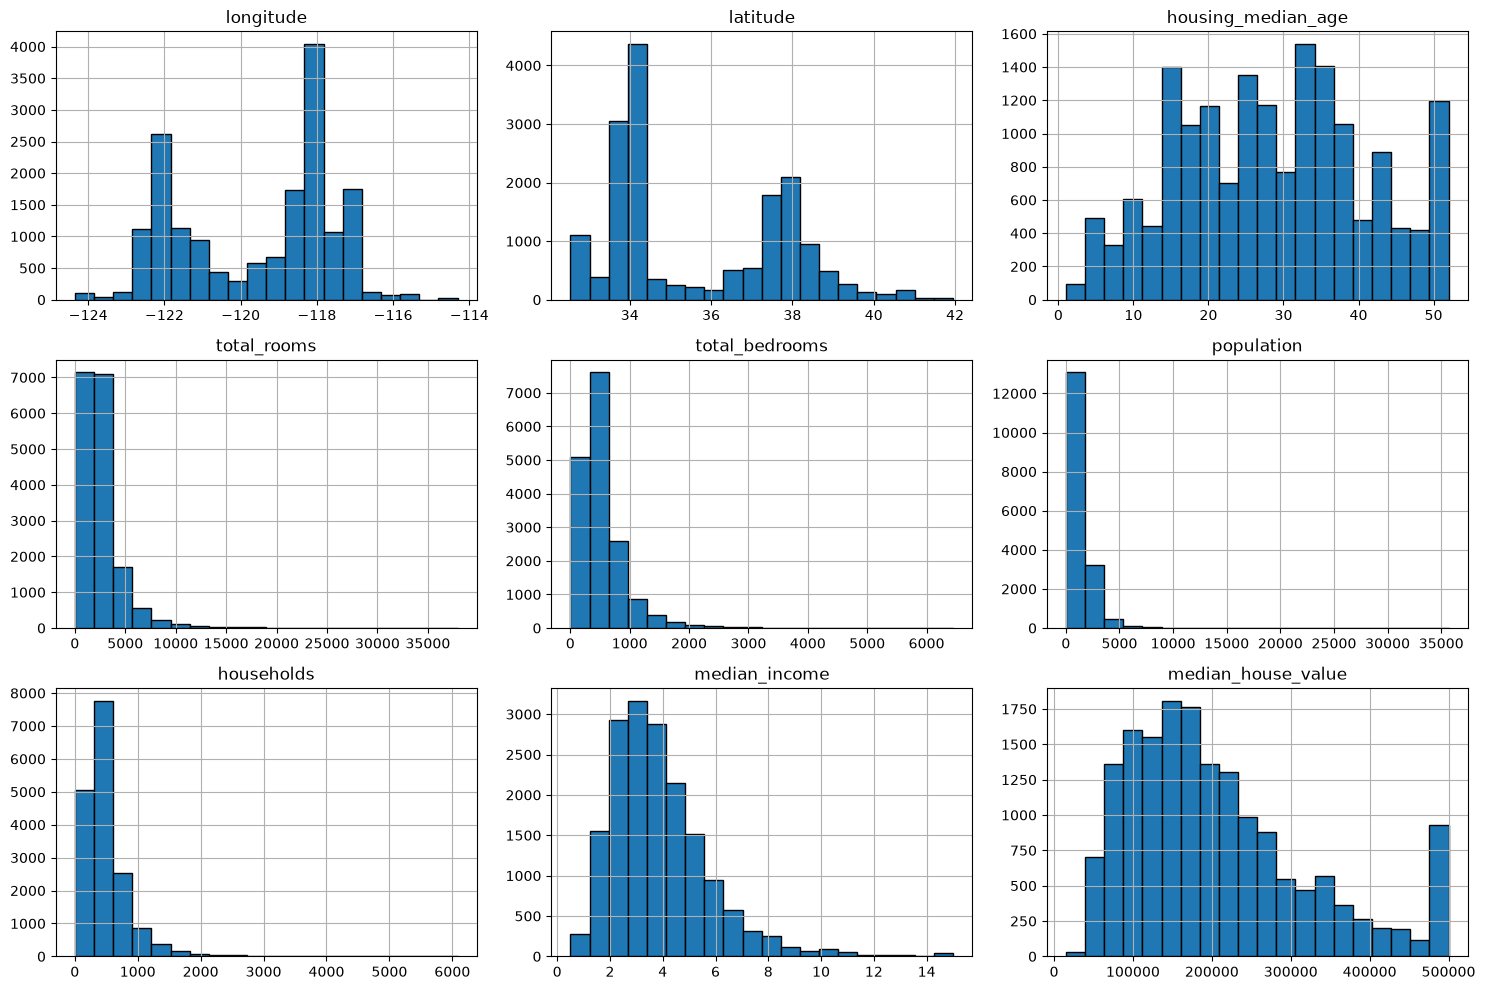

In [12]:
df.hist(bins = 20, figsize=(15, 10), layout=(3, 3), edgecolor="black")
plt.tight_layout()
plt.show()

## Geographic distribution of households

Each point represents a housing district. Darker colors indicate more households; values are capped at the 99th percentile to keep extreme districts from dominating the color scale.

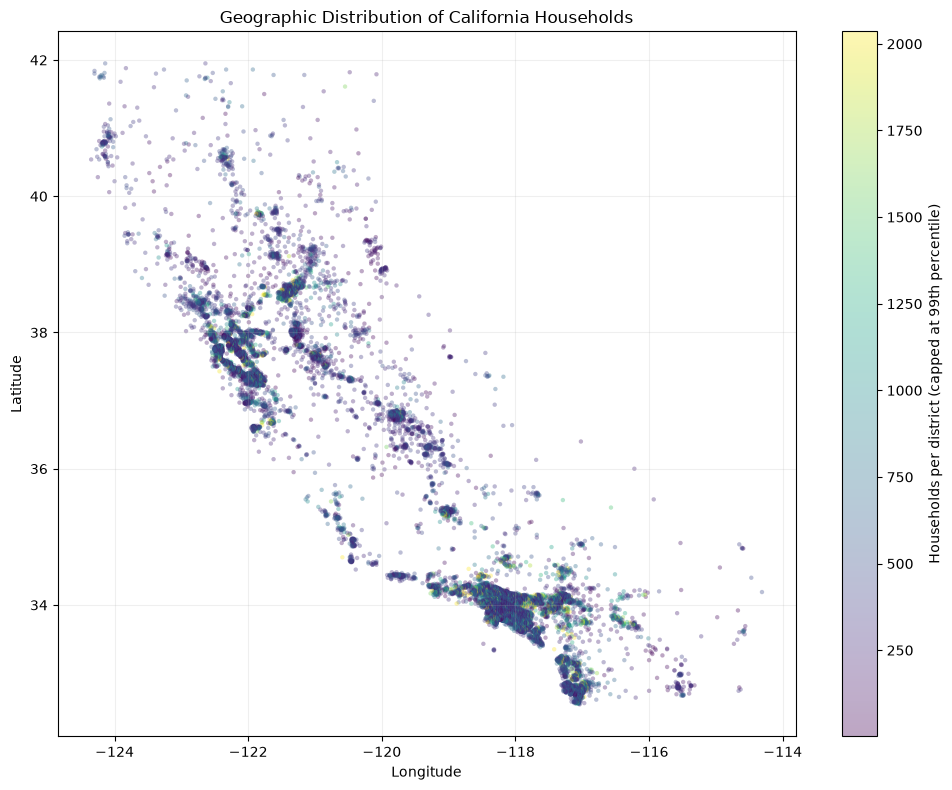

In [13]:
household_color = df["households"].clip(upper=df["households"].quantile(0.99))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=household_color,
    cmap="viridis",
    s=10,
    alpha=0.35,
    edgecolors="none",
)
plt.colorbar(scatter, label="Households per district (capped at 99th percentile)")
plt.title("Geographic Distribution of California Households")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [20]:
df.corr()['median_house_value'].sort_values(ascending= False)

median_house_value    1.000000
median_income         0.691871
total_rooms           0.130991
housing_median_age    0.106758
households            0.061031
total_bedrooms        0.045783
population           -0.027850
longitude            -0.044982
latitude             -0.144917
Name: median_house_value, dtype: float64

In [21]:
def engineered_feat(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    df['room_per_house'] = df['total_rooms']/df['households']
    df['bedroom_per_house'] = df['total_bedrooms']/df['households']
    df['population_per_house'] = df['population']/df['households']
    return df

df = engineered_feat(df)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,room_per_house,bedroom_per_house,population_per_house
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,11.889831,2.718220,2.150424
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,16.522678,4.105832,2.438445
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,6.153846,1.487179,2.846154
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,6.641593,1.491150,2.278761
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,5.549618,1.244275,2.381679


In [23]:
df.corr()['median_house_value'].sort_values(ascending = False)

median_house_value      1.000000
median_income           0.691871
room_per_house          0.150081
total_rooms             0.130991
housing_median_age      0.106758
households              0.061031
total_bedrooms          0.045783
population             -0.027850
population_per_house   -0.042764
longitude              -0.044982
bedroom_per_house      -0.045668
latitude               -0.144917
Name: median_house_value, dtype: float64